# v10_9264 — forced 1:2 R:R test

This notebook re-runs strategy `v10_9264` on the OOS test partition with its
planned R:R forced to **2.0** (vs the original **1.11** that the sweep chose).
All other parameters are kept intact (stop_fixed_pts = 2.065, z_band_k = 2.007,
z_window = 23, ema 5/47, max_hold_bars = 15, breakeven stop on,
exit-on-opposite on).

Only `min_rr` changes. That widens TP from ~2.3 pts to ~4.13 pts — comfortably
above the break-even target implied by a $5/contract round-trip cost model
(≈ 2.5 pts gross per contract at MNQ's $2/pt).

Cost model (net columns): every trade is charged `contracts × $5.00` round-trip
(≈ $3 retail commission + 2 ticks/side slippage on MNQ at $0.50/tick).


In [1]:
import sys, copy, json
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES, DEFAULT_COST_PER_CONTRACT_RT,
    apply_sizing, metrics_from_pnl, monte_carlo,
)
from scripts.evaluation.composed_strategy_runner import run_strategy, load_test_bars

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')

bars = load_test_bars()
YEARS_SPAN = ((pd.to_datetime(bars['time'].iloc[-1]) - pd.to_datetime(bars['time'].iloc[0]))
              .total_seconds() / (365.25 * 86400))
print(f'OOS bars: {len(bars):,}  span {YEARS_SPAN:.3f} yr')

COST = DEFAULT_COST_PER_CONTRACT_RT
print(f'Cost model: ${COST:.2f}/contract round-trip')

payload = json.loads((REPO / 'evaluation/top_strategies.json').read_text())
s_orig = next(s for s in payload['top'] if s['global_combo_id'] == 'v10_9264')
s_rr2 = copy.deepcopy(s_orig)
s_rr2['parameters']['min_rr'] = 2.0
s_rr2['global_combo_id'] = 'v10_9264_rr2'
print(f"min_rr original = {s_orig['parameters']['min_rr']:.3f}")
print(f"min_rr forced   = {s_rr2['parameters']['min_rr']:.3f}")


OOS bars: 514,563  span 1.461 yr
Cost model: $5.00/contract round-trip
min_rr original = 1.111
min_rr forced   = 2.000


In [2]:
r_orig = run_strategy(s_orig, bars=bars)
print(f"RR 1.11: {len(r_orig['trades']):,} trades")
r_rr2 = run_strategy(s_rr2, bars=bars)
print(f"RR 2.00: {len(r_rr2['trades']):,} trades")


RR 1.11: 10,757 trades


RR 2.00: 10,755 trades


In [3]:
def net_of(trades, cost):
    if trades.empty:
        return trades
    t = trades.copy()
    t['actual_pnl'] = t['actual_pnl'] - t['contracts'] * cost
    return t

variants = {
    'RR 1.11 gross': r_orig['trades'],
    'RR 1.11 net'  : net_of(r_orig['trades'], COST),
    'RR 2.00 gross': r_rr2['trades'],
    'RR 2.00 net'  : net_of(r_rr2['trades'], COST),
}
for name, t in variants.items():
    tot = t['actual_pnl'].sum() if not t.empty else 0.0
    print(f'  {name:>14s}: {len(t):>6,} trades  total ${tot:>14,.2f}')


   RR 1.11 gross: 10,757 trades  total $  1,831,784.55
     RR 1.11 net: 10,757 trades  total $ -4,676,200.45
   RR 2.00 gross: 10,755 trades  total $  2,513,836.71
     RR 2.00 net: 10,755 trades  total $ -3,992,938.29


In [4]:
rows = []
for name, t in variants.items():
    if t.empty:
        continue
    pnl = t['actual_pnl'].to_numpy(dtype=float)
    risk = t['dollar_risk'].to_numpy(dtype=float)
    r_mult = np.where(risk > 0, pnl / risk, 0.0)
    rows.append({'variant': name,
                 **metrics_from_pnl(pnl, YEARS_SPAN, policy='fixed_dollars_500')})
summary = pd.DataFrame(rows)
summary


,variant,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,RR 1.11 gross,10757,7362.7,0.6163,1831784.55,3663.57,29.4201,12.42,7668.68
1,RR 1.11 net,10757,7362.7,0.0000,-4676200.45,-9352.40,-75.1039,9352.40,4676200.45
2,RR 2.00 gross,10755,7361.4,0.4060,2513836.71,5027.67,30.3590,19.29,12992.98
3,RR 2.00 net,10755,7361.4,0.4055,-3992938.29,-7985.88,-48.2217,7987.45,3993727.21


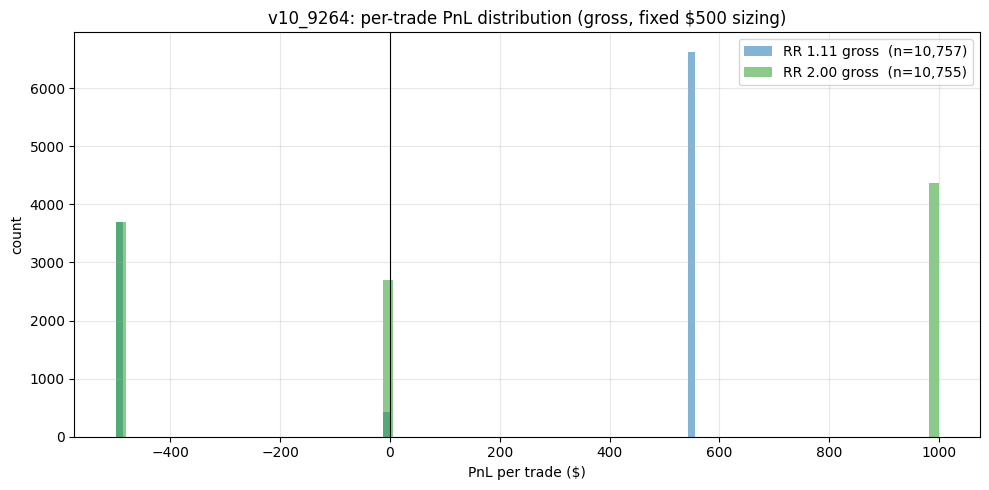

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, colour in [('RR 1.11 gross', '#1f77b4'), ('RR 2.00 gross', '#2ca02c')]:
    t = variants[name]
    if t.empty:
        continue
    ax.hist(t['actual_pnl'], bins=80, alpha=0.55, label=f'{name}  (n={len(t):,})', color=colour)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_title('v10_9264: per-trade PnL distribution (gross, fixed $500 sizing)')
ax.set_xlabel('PnL per trade ($)'); ax.set_ylabel('count'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


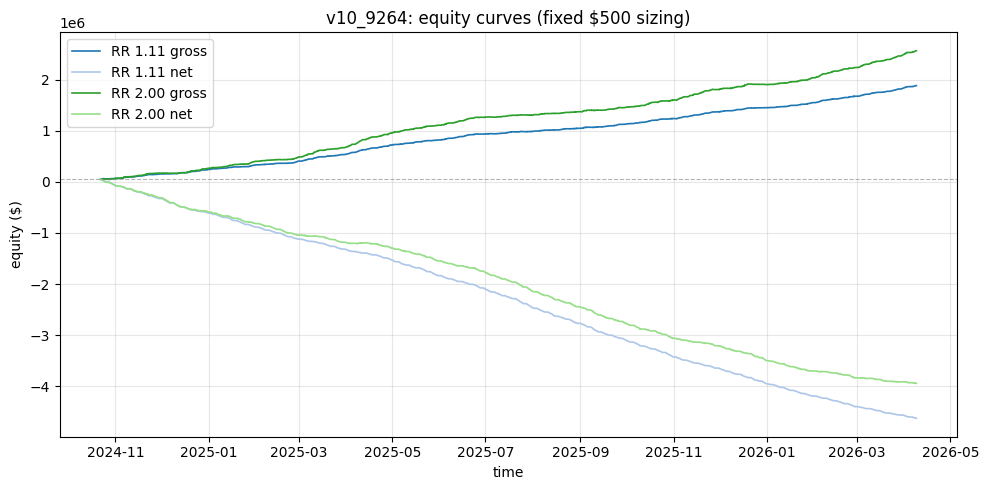

In [6]:
palette = {'RR 1.11 gross': '#1f77b4', 'RR 1.11 net': '#aec7e8',
           'RR 2.00 gross': '#2ca02c', 'RR 2.00 net': '#98df8a'}

fig, ax = plt.subplots(figsize=(10, 5))
for name, t in variants.items():
    if t.empty:
        continue
    t = t.sort_values('date')
    eq = STARTING_EQUITY + t['actual_pnl'].cumsum()
    ax.plot(t['date'], eq, linewidth=1.2, label=name, color=palette[name])
ax.axhline(STARTING_EQUITY, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('v10_9264: equity curves (fixed $500 sizing)')
ax.set_xlabel('time'); ax.set_ylabel('equity ($)'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


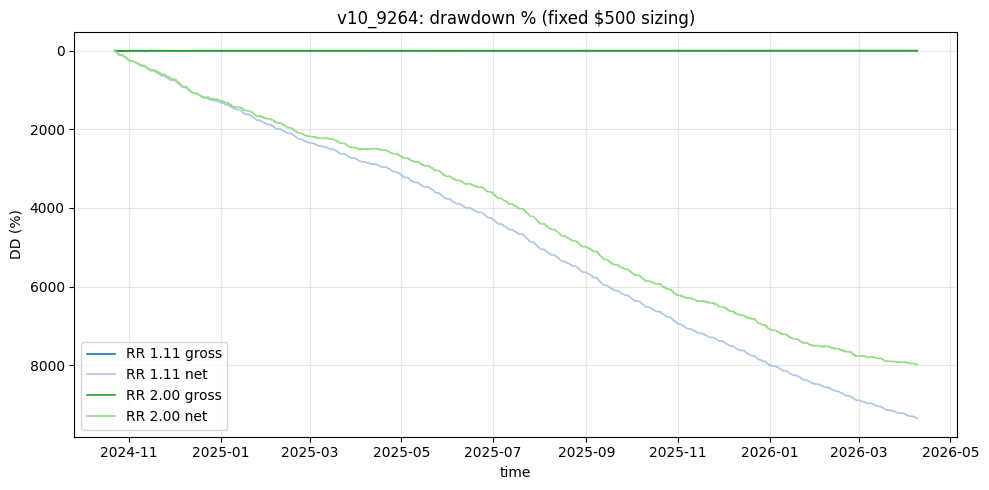

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, t in variants.items():
    if t.empty:
        continue
    t = t.sort_values('date')
    eq = np.concatenate([[STARTING_EQUITY],
                         (STARTING_EQUITY + t['actual_pnl'].cumsum()).to_numpy()])
    peak = np.maximum.accumulate(eq)
    dd = np.nan_to_num((peak - eq) / peak, nan=0.0) * 100
    times = pd.concat([pd.Series([t['date'].iloc[0]]),
                       pd.Series(t['date'].values)]).reset_index(drop=True)
    ax.plot(times, dd, linewidth=1.2, label=name, color=palette[name])
ax.invert_yaxis()
ax.set_title('v10_9264: drawdown % (fixed $500 sizing)')
ax.set_xlabel('time'); ax.set_ylabel('DD (%)'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


In [8]:
rows = []
for name in ['RR 1.11 net', 'RR 2.00 net']:
    t = variants[name]
    if t.empty:
        continue
    pnl = t['actual_pnl'].to_numpy(dtype=float)
    risk = t['dollar_risk'].to_numpy(dtype=float)
    for policy in POLICIES:
        rows.append({'variant': name, 'policy': policy,
                     **monte_carlo(pnl, risk, policy, YEARS_SPAN)})
mc_tbl = pd.DataFrame(rows)
mc_tbl[['variant', 'policy', 'n_trades', 'win_rate', 'sharpe_p50',
        'sharpe_ci_95', 'dd_p50_pct', 'dd_p99_pct',
        'risk_of_ruin_prob', 'sharpe_pos_prob']]


,variant,policy,n_trades,win_rate,sharpe_p50,sharpe_ci_95,dd_p50_pct,dd_p99_pct,risk_of_ruin_prob,sharpe_pos_prob
0,RR 1.11 net,fixed_dollars_500,10757,0.0000,-75.1040,"(-76.343, -73.8601)",9351.59,9590.15,1.0,0.0
1,RR 1.11 net,pct5_compound,10757,0.0000,-74.5443,"(-75.7843, -73.2984)",100.00,100.00,1.0,0.0
2,RR 2.00 net,fixed_dollars_500,10755,0.4054,-48.2366,"(-49.9267, -46.5331)",7941.16,8284.54,1.0,0.0
3,RR 2.00 net,pct5_compound,10755,0.4054,-50.4158,"(-52.1029, -48.7217)",100.00,100.00,1.0,0.0
